In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random

In [2]:
n = 10
w_max = 900
f_s = 1000
t_max = 256 / f_s

In [3]:
def generate_random_signal(n_harmonics, w_max, time_array):
    signal = np.zeros_like(time_array)
    dw = w_max / n_harmonics

    amplitudes = []
    phases = []
    frequencies = []

    for j in range(1, n_harmonics + 1):
        w_j = j * dw
        A_j = random.uniform(0, 1)
        phi_j = random.uniform(0, 2 * np.pi)

        signal += A_j * np.sin(w_j * time_array + phi_j)

        amplitudes.append(A_j)
        phases.append(phi_j)
        frequencies.append(w_j)

    return signal, amplitudes, phases, frequencies

In [8]:
t = np.linspace(0, t_max, int(t_max * f_s))
x_signal, A_x, phi_x, w_x = generate_random_signal(n, w_max, t)

mean_x = np.mean(x_signal)
var_x = np.var(x_signal)
std_x = np.std(x_signal)

print('Статистичні параметри для сигналу 1')
print(f'Кількість гармонік: {n}')
print(f'Гранична частота: {w_max}')
print(f'Математичне сподівання: {mean_x:.4f}')
print(f'Дисперсія: {var_x:.4f}')
print(f'Стандартне відхилення: {std_x:.4f}')

Статистичні параметри для сигналу 1
Кількість гармонік: 10
Гранична частота: 900
Математичне сподівання: 0.0292
Дисперсія: 1.2570
Стандартне відхилення: 1.1211


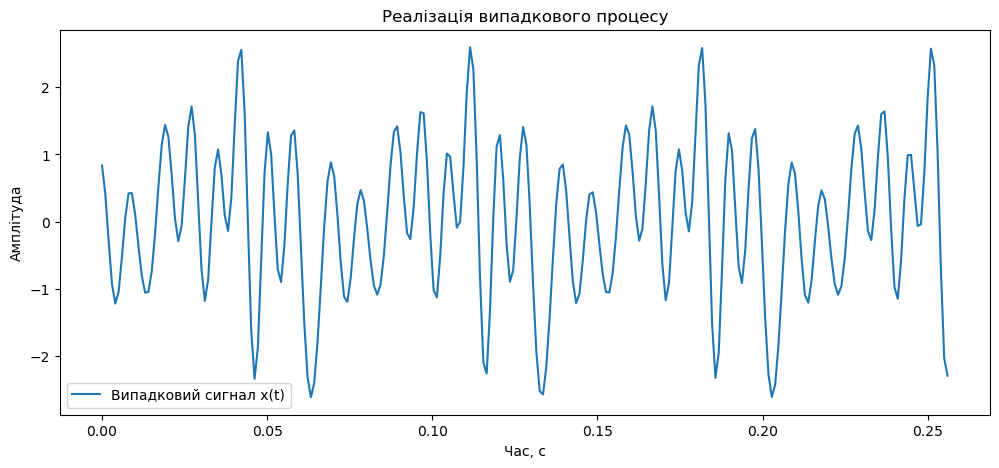

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(t, x_signal, label='Випадковий сигнал x(t)')
plt.title(f'Реалізація випадкового процесу')
plt.xlabel('Час, с')
plt.ylabel('Амплітуда')
plt.legend()
plt.show()

In [6]:
def calculate_correlation(sig1, sig2):
    corr = np.correlate(sig1 - np.mean(sig1), sig2 - np.mean(sig2), mode='full')
    normalization = (len(sig1) * np.std(sig1) * np.std(sig2))
    return corr / normalization

acf_x = calculate_correlation(x_signal, x_signal)
lags = np.arange(-len(x_signal) + 1, len(x_signal))
tau = lags / f_s

y_signal, A_x_1, phi_x_1, w_x_1 = generate_random_signal(n, w_max, t)

# Взаємно-кореляційна функція між x(t) та y(t)
ccf_xy = calculate_correlation(x_signal, y_signal)
mean_x_1 = np.mean(x_signal)
var_x_1 = np.var(x_signal)
std_x_1 = np.std(x_signal)

print('Статистичні параметри для сигналу 2')
print(f'Математичне сподівання: {mean_x:.4f}')
print(f'Дисперсія: {var_x:.4f}')
print(f'Стандартне відхилення: {std_x:.4f}')

Статистичні параметри для сигналу 2
Математичне сподівання: -0.0372
Дисперсія: 2.4717
Стандартне відхилення: 1.5722


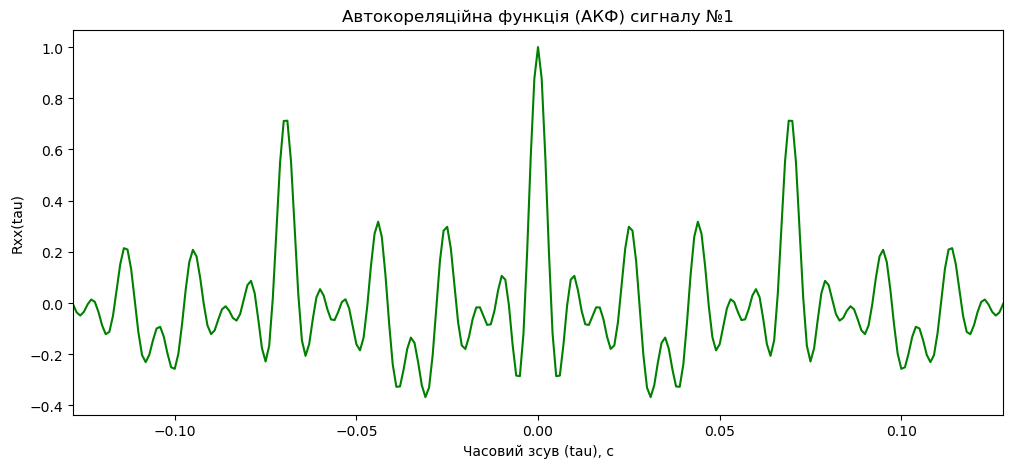

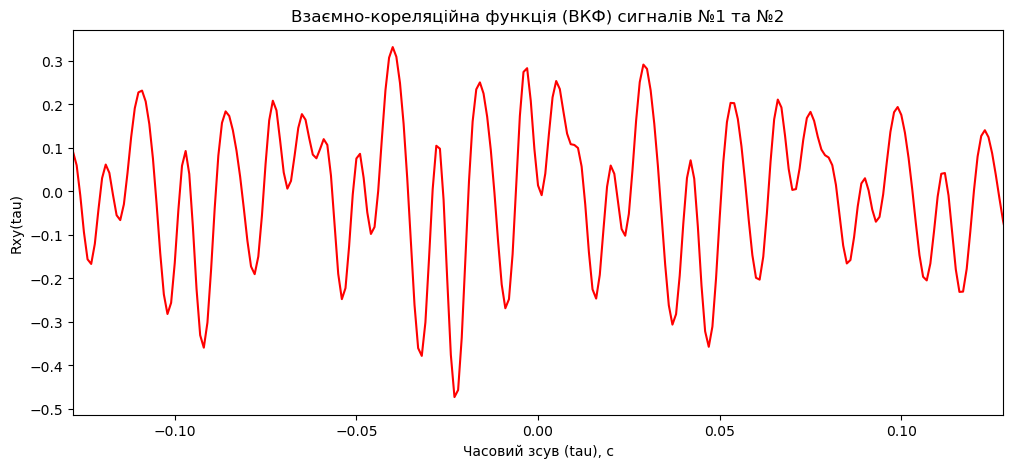

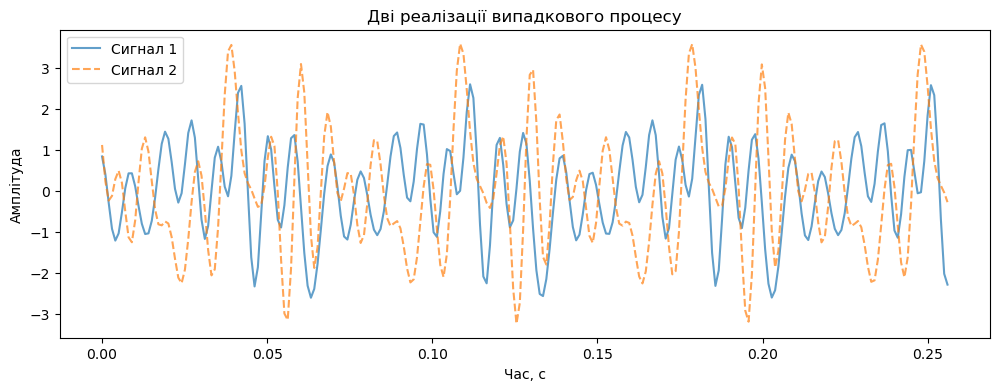

In [10]:
# Візуалізація автокореляційної функції
plt.figure(figsize=(12, 5))
plt.plot(tau, acf_x, color='green')
plt.title('Автокореляційна функція (АКФ) сигналу №1')
plt.xlabel('Часовий зсув (tau), с')
plt.ylabel('Rxx(tau)')
plt.xlim(-t_max/2, t_max/2)
plt.show()

# Візуалізація взаємно-кореляційної функції
plt.figure(figsize=(12, 5))
plt.plot(tau, ccf_xy, color='red')
plt.title('Взаємно-кореляційна функція (ВКФ) сигналів №1 та №2')
plt.xlabel('Часовий зсув (tau), с')
plt.ylabel('Rxy(tau)')
plt.xlim(-t_max/2, t_max/2)
plt.show()

plt.figure(figsize=(12, 4))
plt.plot(t, x_signal, alpha=0.7, label='Сигнал 1')
plt.plot(t, y_signal, alpha=0.7, label='Сигнал 2', linestyle='--')
plt.title('Дві реалізації випадкового процесу')
plt.xlabel('Час, с')
plt.ylabel('Амплітуда')
plt.legend()
plt.show()